## Most Optimal Skills to Learn for Data Engineer

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import ast

# load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# clean-up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x:
        ast.literal_eval(x)
        if pd.notna(x)
        else(x)
)

In [2]:
# filter only Data Engineer and United States
df_de_us = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()

df_de_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p..."
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN
27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"[python, r, java]","{'programming': ['python', 'r', 'java']}"


In [3]:
# drop the NaN value for salary_year_avg
df_de_us = df_de_us.dropna(subset='salary_year_avg')

df_de_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."
307,Data Engineer,Data Engineer,"Austin, TX",via LinkedIn,Full-time,False,"New York, United States",2023-10-03 13:05:31,False,False,United States,year,185000.0,NaN,hackajob,"[nosql, sql]","{'programming': ['nosql', 'sql']}"
339,Data Engineer,Global Market Leading Energy Firm - Staff Data...,United States,via LinkedIn,Full-time,False,"California, United States",2023-09-22 13:07:57,False,False,United States,year,195000.0,NaN,Xcede,NaN,NaN
380,Data Engineer,Snaplogic Data Engineer,"Durham, NC",via LinkedIn,Full-time,False,"Illinois, United States",2023-08-16 13:26:21,True,False,United States,year,97500.0,NaN,KTek Resourcing,"[sql, python]","{'programming': ['sql', 'python']}"


In [4]:
# explode the job_skills to count it later
df_de_us_exploded = df_de_us.explode('job_skills').copy()

df_de_us_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
92,120000.0,sql
92,120000.0,python
146,129500.0,golang
146,129500.0,scala
146,129500.0,python


In [5]:
# group by job_skills, and aggregate the salary year avg median & count the job_skills, sorted out by count
df_de_skills = df_de_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

# rename the columns
df_de_skills = df_de_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_de_skills

,skill_count,median_salary
job_skills,,
sql,2110,125000.00000
python,2007,127794.50000
aws,1313,131000.00000
spark,968,137410.15625
azure,961,125000.00000
...,...,...
vue,1,200000.00000
vue.js,1,116250.00000
wire,1,90000.00000


In [6]:
# add column for conversion the skill_count to pct %
de_job_count = len(df_de_us)

df_de_skills['skill_pct'] = 100 * (df_de_skills['skill_count'] / de_job_count)

df_de_skills

,skill_count,median_salary,skill_pct
job_skills,,,
sql,2110,125000.00000,72.384220
python,2007,127794.50000,68.850772
aws,1313,131000.00000,45.042882
spark,968,137410.15625,33.207547
azure,961,125000.00000,32.967410
...,...,...,...
vue,1,200000.00000,0.034305
vue.js,1,116250.00000,0.034305
wire,1,90000.00000,0.034305


In [7]:
# filter out the dataframe to only show skill_pct > 15%

skill_pct_limit = 15

df_skills = df_de_skills[df_de_skills['skill_pct'] > skill_pct_limit]

df_skills

,skill_count,median_salary,skill_pct
job_skills,,,
sql,2110,125000.00000,72.384220
python,2007,127794.50000,68.850772
aws,1313,131000.00000,45.042882
spark,968,137410.15625,33.207547
azure,961,125000.00000,32.967410
snowflake,765,130700.00000,26.243568
java,732,137000.00000,25.111492
kafka,536,145000.00000,18.387650
nosql,519,140000.00000,17.804460


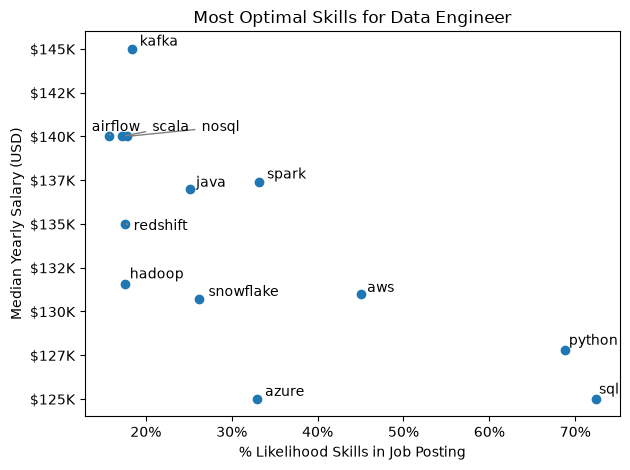

In [8]:
# scatter plot it
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

plt.scatter(df_skills['skill_pct'], df_skills['median_salary'])

plt.title('Most Optimal Skills for Data Engineer')
plt.xlabel('% Likelihood Skills in Job Posting')
plt.ylabel('Median Yearly Salary (USD)')

# format the xaxis & yaxis
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda y, _:
        f'${int(y / 1000)}K'
    )
)

# add label to each dots
texts = []
for i, txt in enumerate(df_skills.index):
    texts.append(
        plt.text(
            df_skills['skill_pct'].iloc[i],
            df_skills['median_salary'].iloc[i],
            " " + txt
        )
    )

# adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()


### Skills Classification by Technology

In [9]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['dax',
  'sheets',
  'word',
  'excel',
  'visio',
  'sap',
  'power bi',
  'ssrs',
  'ms access',
  'spreadsheet',
  'nuix',
  'microstrategy',
  'looker',
  'msaccess',
  'datarobot',
  'qlik',
  'spss',
  'sas',
  'cognos',
  'esquisse',
  'splunk',
  'alteryx',
  'tableau',
  'sharepoint',
  'outlook',
  'powerbi',
  'powerpoint',
  'ssis'],
 'programming': ['golang',
  't-sql',
  'erlang',
  'java',
  'assembly',
  'c',
  'vba',
  'objective-c',
  'delphi',
  'typescript',
  'elixir',
  'shell',
  'sass',
  'sql',
  'visual basic',
  'f#',
  'groovy',
  'rust',
  'css',
  'r',
  'javascript',
  'html',
  'vb.net',
  'ocaml',
  'crystal',
  'lua',
  'mongo',
  'perl',
  'sas',
  'swift',
  'python',
  'c++',
  'go',
  'mongodb',
  'c#',
  'fortran',
  'pascal',
  'bash',
  'apl',
  'julia',
  'visualbasic',
  'nosql',
  'cobol',
  'haskell',
  'php',
  'powershell',
  'clojure',
  'no-sql',
  'lisp',
  'ruby',
  'matlab',
  'scala',
  'kotlin',
  'dart',
  'solid

In [10]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,dax
0,analyst_tools,sheets
0,analyst_tools,word
0,analyst_tools,excel
0,analyst_tools,visio
...,...,...
9,sync,webex
9,sync,rocketchat
9,sync,twilio
9,sync,zoom


In [11]:
# merge df_skills and df_technology
df_plot = df_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skill_pct,technology,skills
0,2110,125000.00000,72.384220,programming,sql
1,2007,127794.50000,68.850772,programming,python
2,1313,131000.00000,45.042882,cloud,aws
3,968,137410.15625,33.207547,libraries,spark
4,961,125000.00000,32.967410,cloud,azure
5,765,130700.00000,26.243568,cloud,snowflake
6,732,137000.00000,25.111492,programming,java
7,536,145000.00000,18.387650,libraries,kafka
8,519,140000.00000,17.804460,programming,nosql
9,514,135000.00000,17.632933,cloud,redshift


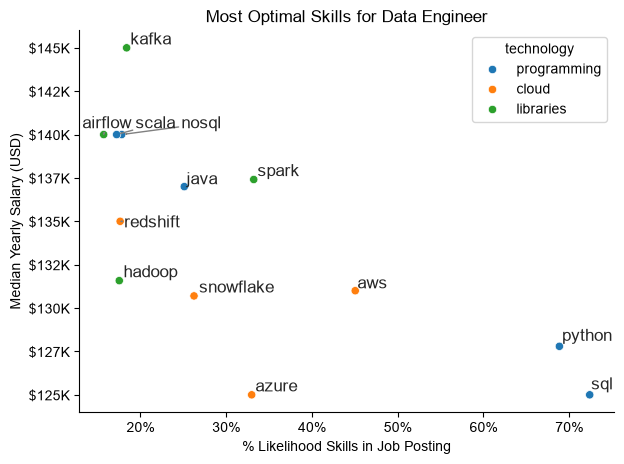

In [12]:
# use seaborn to scatterplot
sns.scatterplot(
    data=df_plot,
    x='skill_pct',
    y='median_salary',
    hue='technology'
)

sns.set_theme(style='ticks')
sns.despine()

plt.title('Most Optimal Skills for Data Engineer')
plt.xlabel('% Likelihood Skills in Job Posting')
plt.ylabel('Median Yearly Salary (USD)')

# format the xaxis & yaxis
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda y, _:
        f'${int(y / 1000)}K'
    )
)

# add label to each dots
texts = []
for i, txt in enumerate(df_skills.index):
    texts.append(
        plt.text(
            df_skills['skill_pct'].iloc[i],
            df_skills['median_salary'].iloc[i],
            txt
        )
    )

# adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()